<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/Timeseries_walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WMT.csv to WMT.csv


In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
!pip install pmdarima
from pmdarima import auto_arima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
# ==============================
# 2. LOAD DATA
# ==============================
walmart = pd.read_csv(
    "WMT.csv",
    parse_dates=["Date"],
    index_col="Date"
)

# Use Adjusted Close (recommended)
df = walmart[["Adj Close"]].rename(columns={"Adj Close": "price"})
df.head()


,price
Date,
1972-08-25,0.036447
1972-08-28,0.036309
1972-08-29,0.035895
1972-08-30,0.035895
1972-08-31,0.035343


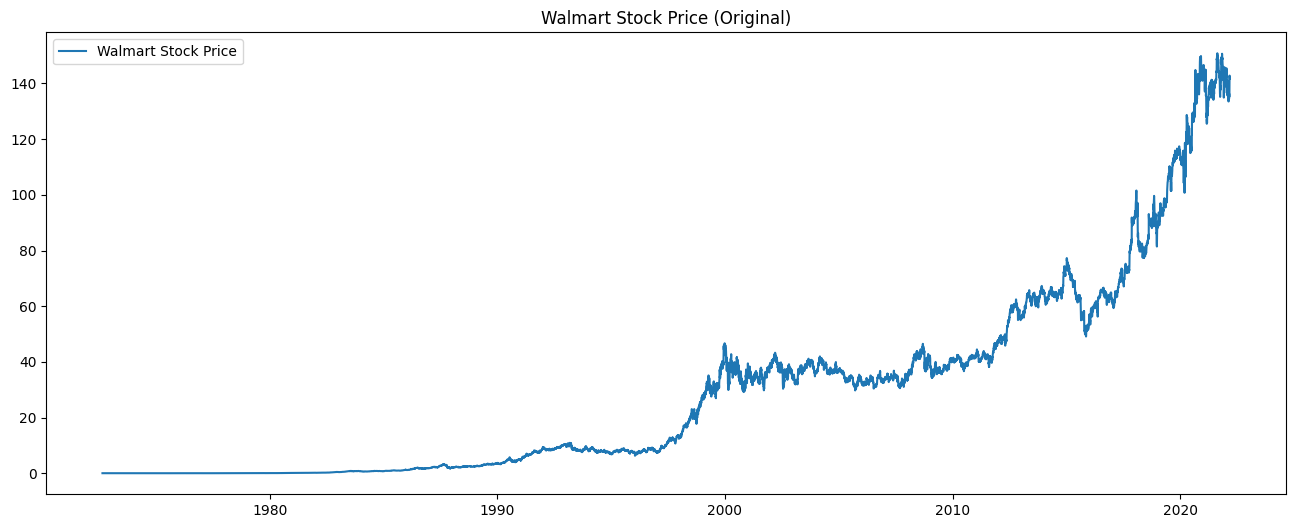

In [ ]:
# ==============================
# 3. VISUALIZE ORIGINAL SERIES
# ==============================
plt.figure(figsize=(16,6))
plt.plot(df, label="Walmart Stock Price")
plt.title("Walmart Stock Price (Original)")
plt.legend()
plt.show()


In [ ]:
# ==============================
# 4. CHECK STATIONARITY
# ==============================
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic : {result[0]}")
    print(f"P-value       : {result[1]}")
    if result[1] <= 0.05:
        print("✔ Stationary")
    else:
        print("✖ Not Stationary")

adf_test(df["price"])


ADF Statistic : 2.762664023886559
P-value       : 1.0
✖ Not Stationary


In [ ]:
# ==============================
# 5. DIFFERENCING (ONCE)
# ==============================
df["price_diff"] = df["price"].diff()
df = df.dropna()

adf_test(df["price_diff"])


ADF Statistic : -18.841845219952024
P-value       : 0.0
✔ Stationary


In [ ]:
# ==============================
# 6. TRAIN–TEST SPLIT
# ==============================
train_size = int(len(df) * 0.95)

train = df.iloc[:train_size]["price_diff"]
test  = df.iloc[train_size:]["price_diff"]

print("Train size:", len(train))
print("Test size :", len(test))


Train size: 11865
Test size : 625


In [ ]:
# ==============================
# 7. AUTO ARIMA (FIND BEST MODEL)
# ==============================
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

auto_model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=43.87 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=24943.184, Time=3.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=21574.136, Time=1.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=28.40 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=24941.184, Time=0.27 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=20009.644, Time=2.44 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=19223.953, Time=2.95 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=18740.938, Time=4.57 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=18299.944, Time=5.28 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=76.71 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=70.98 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AIC=18297.944, Time=1.70 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=18738.939, Time=1.33 sec
 ARIMA(5,1,1)(0,0,0)[0]             : AIC=inf, Time=12.83 sec
 ARIMA(4,1,1)(0,0,0)[0]             : AIC=in

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                11865
Model:               SARIMAX(5, 1, 0)   Log Likelihood               -9142.972
Date:                Mon, 29 Dec 2025   AIC                          18297.944
Time:                        05:08:08   BIC                          18342.232
Sample:                             0   HQIC                         18312.809
                              - 11865                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8505      0.004   -212.080      0.000      -0.858      -0.843
ar.L2         -0.7044      0.005   -130.293      0.000      -0.715      -0.694
ar.L3         -0.5259      0.006    -88.452      0.000      -0.538      -0.514
ar.L4         -0.3557      0.006    -62.208      0.000      -0.367      -0.344
ar.L5         -0.1916      0.004    -44.047      0.000      -0.200      -0.183
sigma2         0.2734      0.001    329.432      0.000       0.272       0.275
===================================================================================
Ljung-Box (L1) (Q):                   9.13   Jarque-Bera (JB):            725685.51
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):            1103.92   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        41.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ==============================
# 8. FIT ARIMA MODEL
# ==============================
model = ARIMA(train, order=auto_model.order)
model_fit = model.fit()

model_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             price_diff   No. Observations:                11865
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -9142.972
Date:                Mon, 29 Dec 2025   AIC                          18297.944
Time:                        05:08:38   BIC                          18342.232
Sample:                             0   HQIC                         18312.809
                              - 11865                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8505      0.004   -212.080      0.000      -0.858      -0.843
ar.L2         -0.7044      0.005   -130.293      0.000      -0.715      -0.694
ar.L3         -0.5259      0.006    -88.452      0.000      -0.538      -0.514
ar.L4         -0.3557      0.006    -62.208      0.000      -0.367      -0.344
ar.L5         -0.1916      0.004    -44.047      0.000      -0.200      -0.183
sigma2         0.2734      0.001    329.432      0.000       0.272       0.275
===================================================================================
Ljung-Box (L1) (Q):                   9.13   Jarque-Bera (JB):            725685.51
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):            1103.92   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        41.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# ==============================
# 9. PREDICTION (DIFFERENCED)
# ==============================
pred_diff = model_fit.forecast(steps=len(test))


In [ ]:
# ==============================
# 10. INVERSE DIFFERENCING
# ==============================
last_price = df.iloc[train_size - 1]["price"]

pred_price = last_price + pred_diff.cumsum()

pred_price.index = df.iloc[train_size:].index


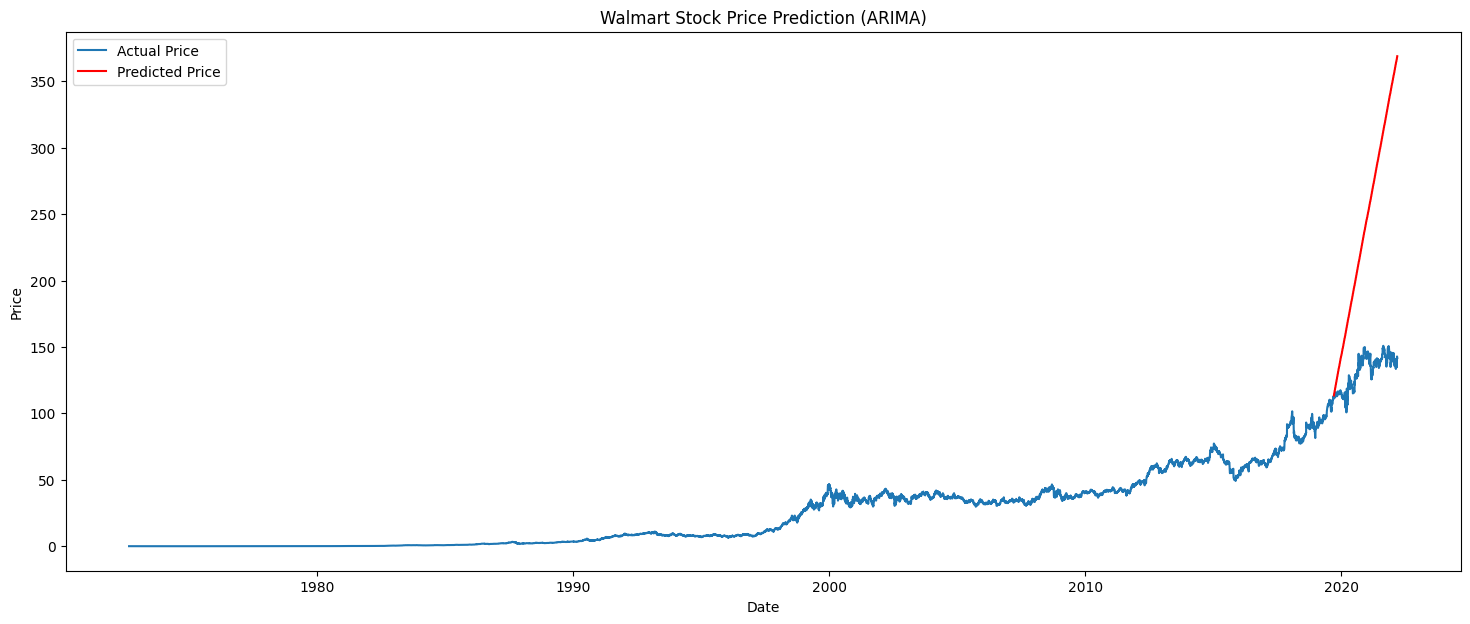

In [ ]:
# ==============================
# 11. FINAL PLOT (CORRECT)
# ==============================
plt.figure(figsize=(18,7))

plt.plot(df["price"], label="Actual Price")
plt.plot(pred_price, label="Predicted Price", color="red")

plt.title("Walmart Stock Price Prediction (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()
model_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             price_diff   No. Observations:                11865
Model:               SARIMAX(5, 1, 0)   Log Likelihood               -9141.070
Date:                Mon, 29 Dec 2025   AIC                          18294.139
Time:                        05:12:33   BIC                          18338.424
Sample:                             0   HQIC                         18309.003
                              - 11865                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8505      0.004   -211.994      0.000      -0.858      -0.843
ar.L2         -0.7044      0.005   -130.244      0.000      -0.715      -0.694
ar.L3         -0.5259      0.006    -88.422      0.000      -0.538      -0.514
ar.L4         -0.3557      0.006    -62.188      0.000      -0.367      -0.345
ar.L5         -0.1916      0.004    -44.033      0.000      -0.200      -0.183
sigma2         0.2736      0.001    329.285      0.000       0.272       0.275
===================================================================================
Ljung-Box (L1) (Q):                   9.11   Jarque-Bera (JB):            724693.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):            1102.48   Skew:                             0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                        41.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
start = len(train)
end   = len(train) + len(test) - 1

pred = model_fit.get_prediction(
    start=start,
    end=end,
    dynamic=False
)

pred_mean = pred.predicted_mean
pred_mean.index = test.index  # reassign correct dates


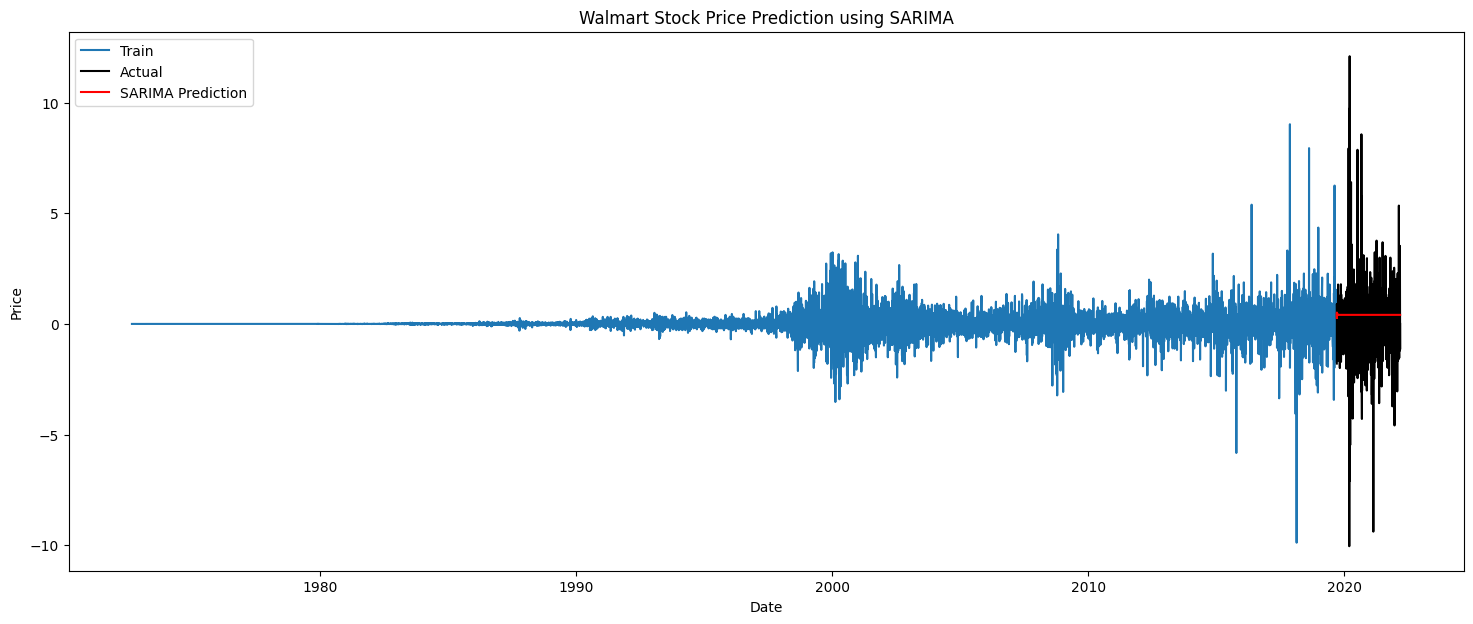

In [ ]:
plt.figure(figsize=(18,7))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(pred_mean.index, pred_mean, label="SARIMA Prediction", color="red")

plt.title("Walmart Stock Price Prediction using SARIMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


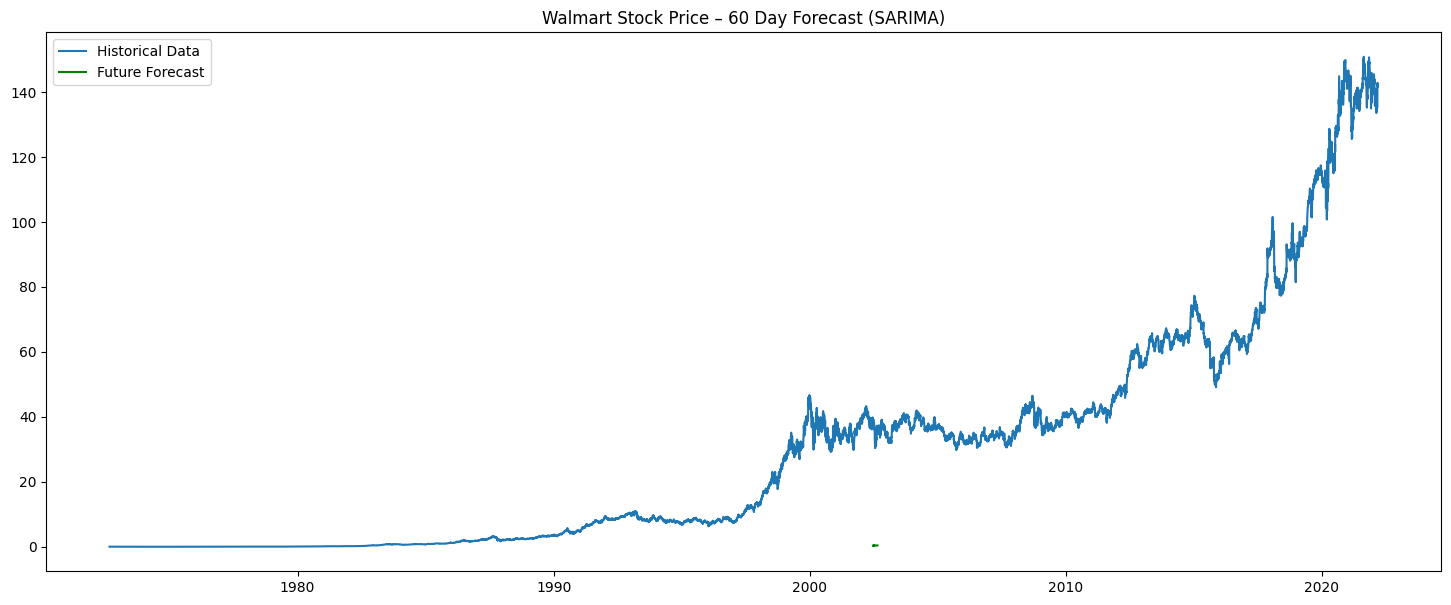

In [ ]:
forecast_steps = 60

forecast = model_fit.forecast(steps=forecast_steps)

plt.figure(figsize=(18,7))
plt.plot(df["price"], label="Historical Data")
plt.plot(forecast.index, forecast, label="Future Forecast", color="green")

plt.title("Walmart Stock Price – 60 Day Forecast (SARIMA)")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller


In [ ]:
walmart = pd.read_csv(
    "WMT.csv",
    parse_dates=["Date"],
    index_col="Date"
)

df = walmart[["Adj Close"]].rename(columns={"Adj Close": "price"})
df.head()


In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df["price"], label="Walmart Price")
plt.title("Walmart Adjusted Close Price")
plt.legend()
plt.show()


In [ ]:
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic : {result[0]}")
    print(f"P-value       : {result[1]}")
    if result[1] <= 0.05:
        print("✔ Stationary")
    else:
        print("✖ Not Stationary")

adf_test(df["price"])


In [ ]:
train_size = int(len(df) * 0.95)

train = df.iloc[:train_size]["price"]
test  = df.iloc[train_size:]["price"]

print("Train:", len(train))
print("Test :", len(test))


In [ ]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=5,               # weekly seasonality
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

auto_model.summary()


In [ ]:
model = SARIMAX(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()
model_fit.summary()


In [ ]:
pred = model_fit.get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)

pred_mean = pred.predicted_mean


In [ ]:
plt.figure(figsize=(18,7))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(pred_mean.index, pred_mean, label="SARIMA Prediction", color="red")

plt.title("Walmart Stock Price Prediction using SARIMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [ ]:
forecast_steps = 60

forecast = model_fit.forecast(steps=forecast_steps)

plt.figure(figsize=(18,7))
plt.plot(df["price"], label="Historical Data")
plt.plot(forecast.index, forecast, label="Future Forecast", color="green")

plt.title("Walmart Stock Price – 60 Day Forecast (SARIMA)")
plt.legend()
plt.show()
